In [5]:
import pandas as pd
import numpy as np
data=pd.read_csv(r"C:\Users\anilp\Downloads\iris.csv")
data
m1=np.mean(data['sepal_length'])
med=np.median(data['sepal_length'])
mod=data['sepal_length'].mode()
var=np.var(data['sepal_length'])
st=np.std(data['sepal_length'])
print("Mean:",m1)
print("Meadian:",med)
print("Mode:",mod)
print("Variance:",var)
print("Standard Deviation:",st)

Mean: 5.843333333333334
Meadian: 5.8
Mode: 0    5.0
Name: sepal_length, dtype: float64
Variance: 0.6811222222222223
Standard Deviation: 0.8253012917851409


Simple Linear Regression
Intercept: -7.033309600658187
Coefficient: 1.842415037022973
MSE: 0.6158263695342153
RMSE: 0.784746054169255
R2 Score: 0.78132891478703


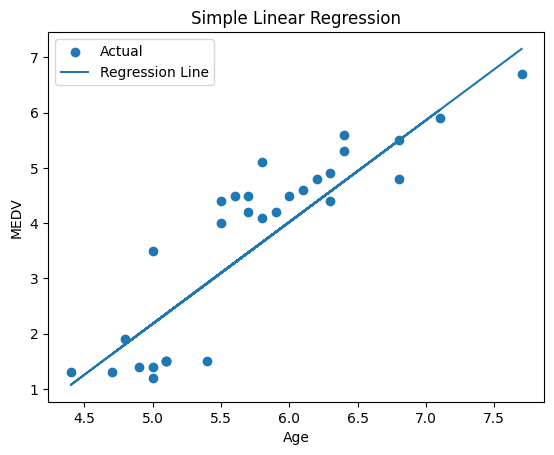

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv(r"C:\Users\anilp\Downloads\iris.csv")
X = df[["sepal_length"]]
y = df["petal_length"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Simple Linear Regression")
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Regression Line")
plt.xlabel("Age")
plt.ylabel("MEDV")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

Multiple Linear Regression
Intercept: -0.22567911487491976
Coefficients: [ 0.75006426 -0.68947844  1.412746  ]
MSE: 0.09902023206666258
RMSE: 0.31467480367303413
R2 Score: 0.9648393399905325


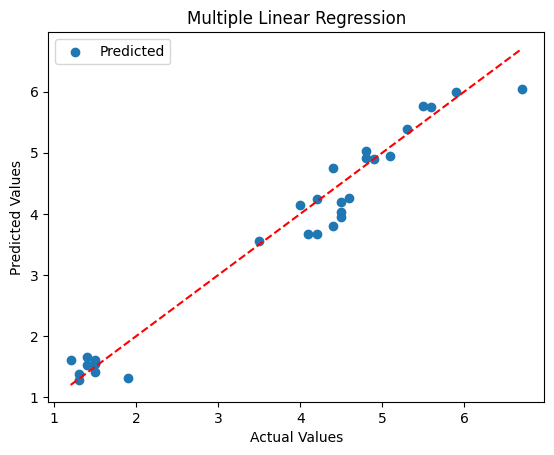

In [7]:
X = df[["sepal_length", "sepal_width", "petal_width"]]
y = df["petal_length"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Multiple Linear Regression")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("MSE:", mse)
print("RMSE:", np.sqrt(mse))
print("R2 Score:", r2_score(y_test, y_pred))
plt.scatter(y_test, y_pred, label="Predicted")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression")
plt.legend()
plt.show()

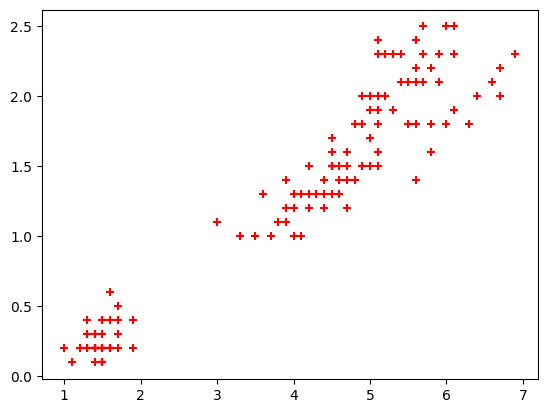

ValueError: could not convert string to float: 'setosa'

In [8]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
df=pd.read_csv(r"C:\Users\anilp\Downloads\iris.csv")
df.head()
plt.scatter(df.petal_length,df.petal_width,marker='+',color='red')
plt.show()
x_train,x_test,y_train,y_test=train_test_split(df[['species']],df.petal_length,train_size=0.8)
model=LogisticRegression()
model.fit(x_train,y_train)
y_predicted=model.predict(x_test)
model.predict_proba(x_test)
model.score(x_test,y_test)
classification_rep=classification_report(y_test,y_predicted)
print(classification_rep)

KNN Accuracy: 1.0
Gaussian NB Accuracy: 0.9666666666666667


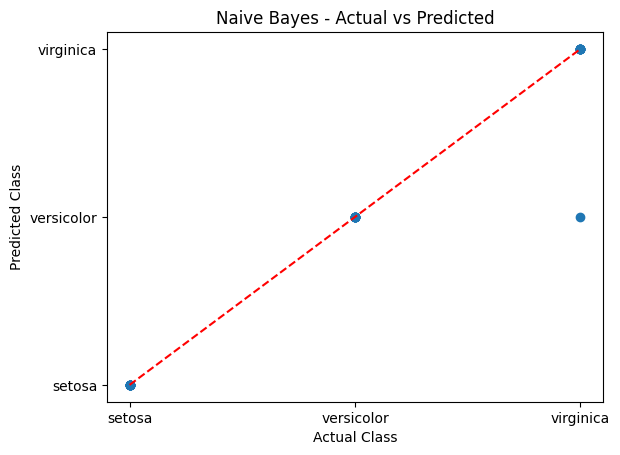

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
data = pd.read_csv(r"C:\Users\anilp\Downloads\iris.csv")
X, y = data.drop("species", axis=1), data["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)
knn = KNeighborsClassifier().fit(X_train, y_train)
print("KNN Accuracy:", accuracy_score(y_test, knn.predict(X_test)))
nb = GaussianNB().fit(X_train, y_train)
y_pred = nb.predict(X_test)
print("Gaussian NB Accuracy:", accuracy_score(y_test, y_pred))
le = LabelEncoder()
le.fit(y)
plt.scatter(le.transform(y_test), le.transform(y_pred))
plt.plot([0, 2], [0, 2], "r--")
plt.xticks([0, 1, 2], le.classes_)
plt.yticks([0, 1, 2], le.classes_)
plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.title("Naive Bayes - Actual vs Predicted")
plt.show()

Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



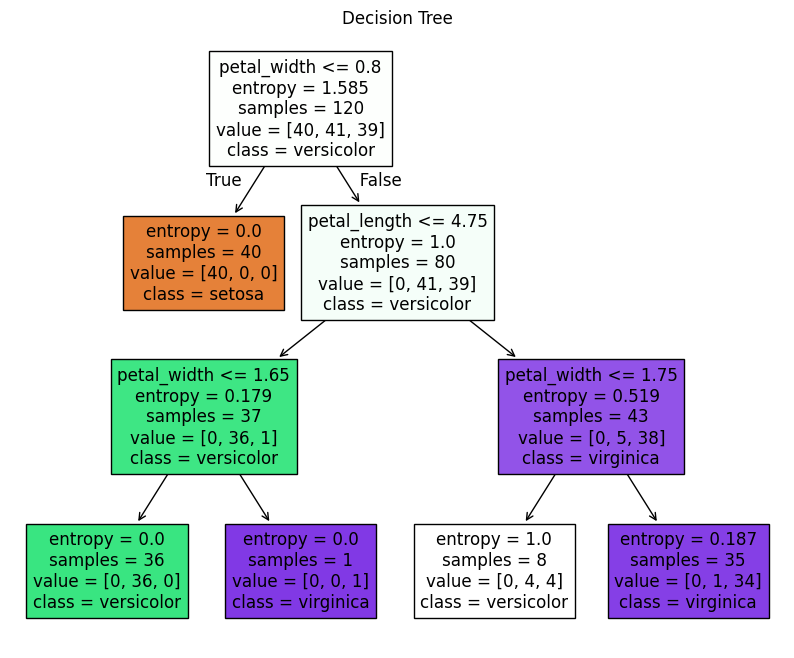

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
data = pd.read_csv(r"C:\Users\anilp\Downloads\iris.csv")
X, y = data.drop("species", axis=1), data["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt = DecisionTreeClassifier(criterion="entropy", max_depth=3)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
plt.figure(figsize=(10, 8))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=y.unique())
plt.title("Decision Tree")
plt.show()

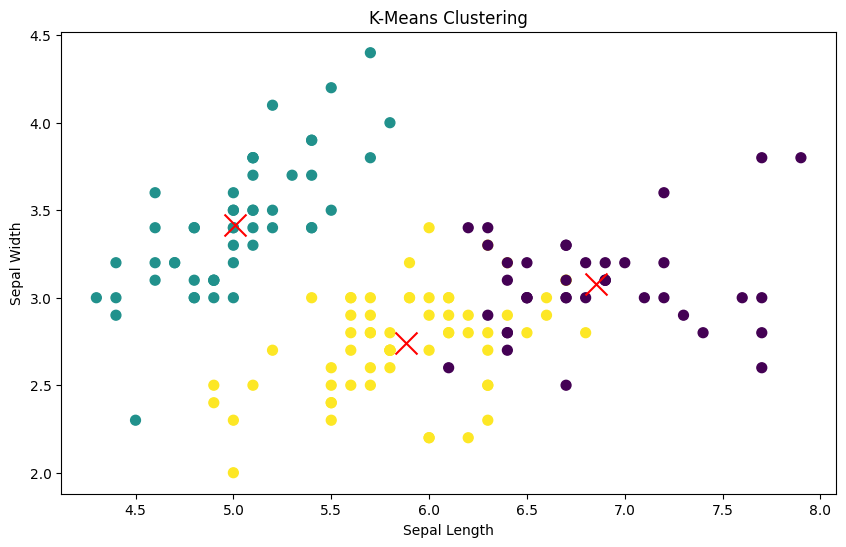

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
data=pd.read_csv(r"C:\Users\anilp\Downloads\iris.csv")
data
x=data.drop('species',axis=1).values
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(x)
cl=kmeans.labels_
ce=kmeans.cluster_centers_
plt.figure(figsize=(10,6))
plt.scatter(x[:,0],x[:,1],c=cl,cmap="viridis",s=50)
plt.scatter(ce[:,0],ce[:,1],c="red",marker='x',s=250)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering")
plt.show()